Primeras filas del dataset:
   customerID Churn  gender  SeniorCitizen Partner Dependents  tenure  \
0  0002-ORFBO    No  Female              0     Yes        Yes       9   
1  0003-MKNFE    No    Male              0      No         No       9   
2  0004-TLHLJ   Yes    Male              0      No         No       4   
3  0011-IGKFF   Yes    Male              1     Yes         No      13   
4  0013-EXCHZ   Yes  Female              1     Yes         No       3   

  PhoneService MultipleLines InternetService  ... OnlineBackup  \
0          Yes            No             DSL  ...          Yes   
1          Yes           Yes             DSL  ...           No   
2          Yes            No     Fiber optic  ...           No   
3          Yes            No     Fiber optic  ...          Yes   
4          Yes            No     Fiber optic  ...           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No         Yes         Yes              No

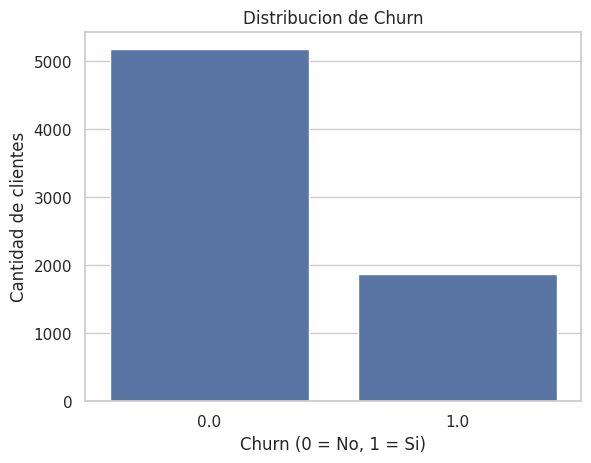


Proporcion de churn (%):
Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


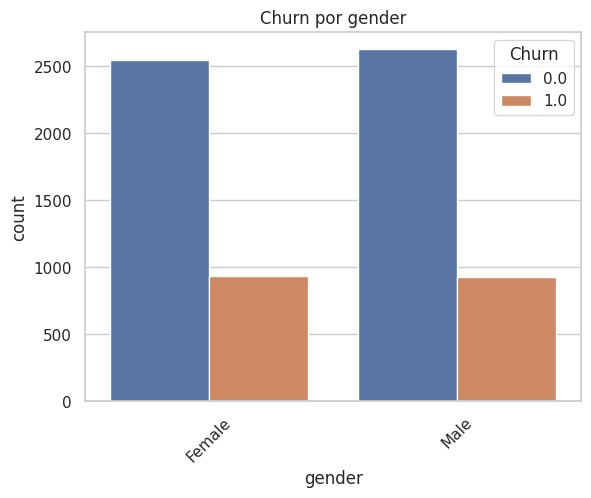

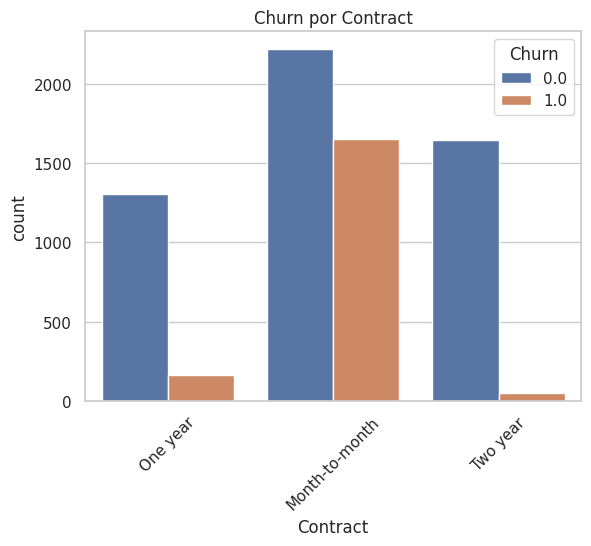

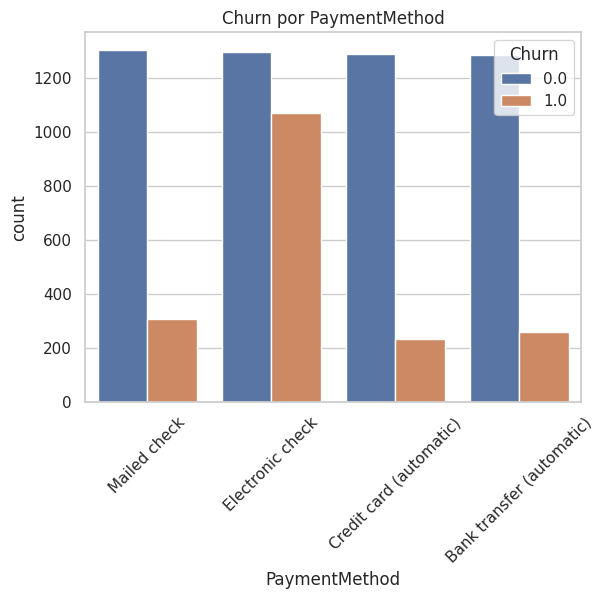

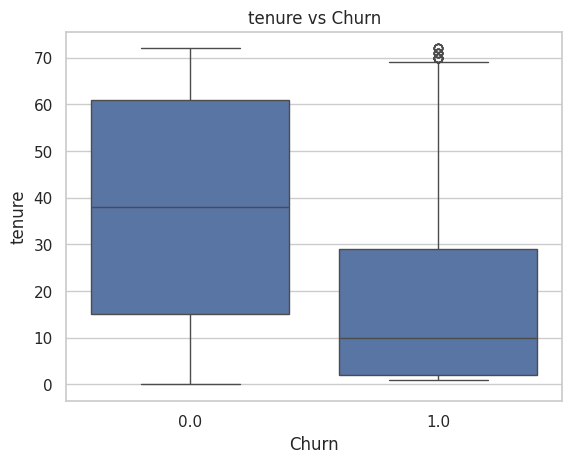


Archivo 'TelecomX_clean.csv' guardado correctamente.

Archivos en el directorio actual:
['.config', 'TelecomX_clean.csv', 'sample_data']

================ INFORME FINAL ================

INTRODUCCION
El objetivo de este analisis es comprender los factores que influyen en la
evasion de clientes (churn) en Telecom X para ayudar a desarrollar estrategias
de retencion de clientes.

LIMPIEZA Y TRATAMIENTO
Se importaron los datos desde un repositorio de GitHub en formato JSON.
Posteriormente se identificaron valores nulos, duplicados y se corrigieron
tipos de datos para variables numericas.

ANALISIS EXPLORATORIO
Se analizaron variables categoricas y numericas relacionadas con la evasion
de clientes mediante graficos de conteo, histogramas y boxplots.

CONCLUSIONES
- Los clientes con contratos mensuales suelen presentar mayor tasa de cancelacion.
- Los cargos mensuales altos pueden asociarse con mayor churn.
- Los clientes con mayor tiempo en la empresa tienden a cancelar menos.

RECOMENDAC

In [12]:
# ================================
# TELECOM X - ANALISIS DE CHURN
# PARTE 1 (EDA + DATA CLEANING)
# ================================

# 1. IMPORTAR LIBRERIAS
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

# ================================
# 2. EXTRACCION DE DATOS
# ================================

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

# ----------------
# Flatten JSON
# ----------------

def flatten_json_column(df, column_name):
    if column_name in df.columns:
        expanded = df[column_name].apply(pd.Series)
        df = pd.concat([df.drop(column_name, axis=1), expanded], axis=1)
    return df

df = flatten_json_column(df, 'customer')
df = flatten_json_column(df, 'phone')
df = flatten_json_column(df, 'internet')
df = flatten_json_column(df, 'account')
df = flatten_json_column(df, 'Charges')

print("Primeras filas del dataset:")
print(df.head())

print("\nDimensiones del dataset:")
print(df.shape)

# ================================
# 3. EXPLORACION DEL DATASET
# ================================

print("\nColumnas del dataset:")
print(df.columns)

print("\nInformacion general:")
print(df.info())

print("\nEstadisticas descriptivas:")
print(df.describe())

# ================================
# 4. IDENTIFICACION DE PROBLEMAS
# ================================

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nRegistros duplicados:")
print(df.duplicated().sum())

print("\nValores unicos en variables categoricas:")
print(df.select_dtypes(include='object').nunique())

# ================================
# 5. LIMPIEZA Y TRATAMIENTO DE DATOS
# ================================

# eliminar duplicados
df = df.drop_duplicates()

# convertir columnas numericas
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

if "MonthlyCharges" in df.columns:
    df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")

# convertir churn a numerico
if "Churn" in df.columns:
    df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# eliminar valores nulos (moved after Churn mapping)
df = df.dropna()

print("\nDataset limpio:")
print(df.head())

# ================================
# 6. ANALISIS DESCRIPTIVO
# ================================

print("\nMedia:")
print(df.mean(numeric_only=True))

print("\nMediana:")
print(df.median(numeric_only=True))

print("\nDesviacion estandar:")
print(df.std(numeric_only=True))

print("\nPromedios agrupados por churn:")
print(df.groupby("Churn").mean(numeric_only=True))

# ================================
# 7. DISTRIBUCION DE EVASION
# ================================

plt.figure()
sns.countplot(x="Churn", data=df)

plt.title("Distribucion de Churn")
plt.xlabel("Churn (0 = No, 1 = Si)")
plt.ylabel("Cantidad de clientes")

plt.show()

print("\nProporcion de churn (%):")
print(df["Churn"].value_counts(normalize=True)*100)

# ================================
# 8. EVASION POR VARIABLES CATEGORICAS
# ================================

categorical_cols = ["gender", "Contract", "PaymentMethod"]

for col in categorical_cols:
    if col in df.columns:

        plt.figure()

        sns.countplot(x=col, hue="Churn", data=df)

        plt.title(f"Churn por {col}")
        plt.xticks(rotation=45)

        plt.show()

# ================================
# 9. EVASION POR VARIABLES NUMERICAS
# ================================

numeric_cols = ["MonthlyCharges", "tenure", "TotalCharges"]

for col in numeric_cols:
    if col in df.columns:

        plt.figure()

        sns.boxplot(x="Churn", y=col, data=df)

        plt.title(f"{col} vs Churn")

        plt.show()

# histograma de cargos mensuales
if "MonthlyCharges" in df.columns:

    plt.figure()

    sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30)

    plt.title("Distribucion de cargos mensuales")

    plt.show()

# ================================
# 10. GUARDAR DATASET LIMPIO
# ================================

df.to_csv("TelecomX_clean.csv", index=False)

print("\nArchivo 'TelecomX_clean.csv' guardado correctamente.")

print("\nArchivos en el directorio actual:")
print(os.listdir())

# ================================
# 11. INFORME FINAL
# ================================

print("\n================ INFORME FINAL ================")

print("""
INTRODUCCION
El objetivo de este analisis es comprender los factores que influyen en la
evasion de clientes (churn) en Telecom X para ayudar a desarrollar estrategias
de retencion de clientes.

LIMPIEZA Y TRATAMIENTO
Se importaron los datos desde un repositorio de GitHub en formato JSON.
Posteriormente se identificaron valores nulos, duplicados y se corrigieron
tipos de datos para variables numericas.

ANALISIS EXPLORATORIO
Se analizaron variables categoricas y numericas relacionadas con la evasion
de clientes mediante graficos de conteo, histogramas y boxplots.

CONCLUSIONES
- Los clientes con contratos mensuales suelen presentar mayor tasa de cancelacion.
- Los cargos mensuales altos pueden asociarse con mayor churn.
- Los clientes con mayor tiempo en la empresa tienden a cancelar menos.

RECOMENDACIONES
- Incentivar contratos de largo plazo.
- Crear estrategias de retencion para clientes nuevos.
- Analizar planes con cargos elevados para mejorar su valor percibido.
""")

In [13]:
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

sns.set(style="whitegrid")

In [14]:
df = pd.read_csv("TelecomX_clean.csv")

print("Dimensiones del dataset:")
print(df.shape)

df.head()

Dimensiones del dataset:
(7043, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,0.0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,0.0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,1.0,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1.0,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1.0,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [15]:
# eliminar ID si existe
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

# convertir churn a numero si esta como texto
if df["Churn"].dtype == "object":
    df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# convertir TotalCharges a numero si existe
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# eliminar valores nulos
df = df.dropna()

print("Valores nulos restantes:")
print(df.isnull().sum().sum())

print("Dataset despues de limpieza:", df.shape)

Valores nulos restantes:
0
Dataset despues de limpieza: (7043, 20)


In [16]:
df = pd.get_dummies(df, drop_first=True)

print("Dataset despues de encoding:")
print(df.shape)

Dataset despues de encoding:
(7043, 6560)


Churn
0.0    5174
1.0    1869
Name: count, dtype: int64


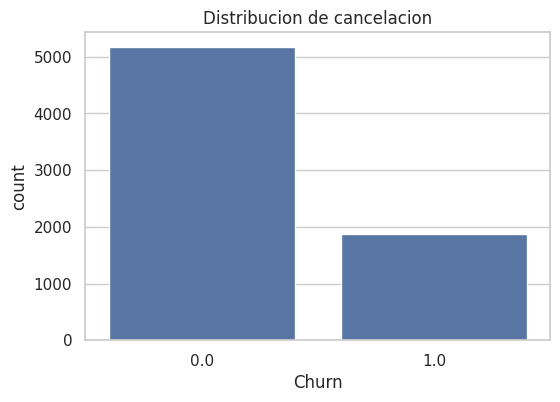

In [17]:
print(df["Churn"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Distribucion de cancelacion")
plt.show()

Variables mas correlacionadas con churn:
Churn            1.000000
Monthly          0.193356
SeniorCitizen    0.150889
tenure          -0.352229
Name: Churn, dtype: float64


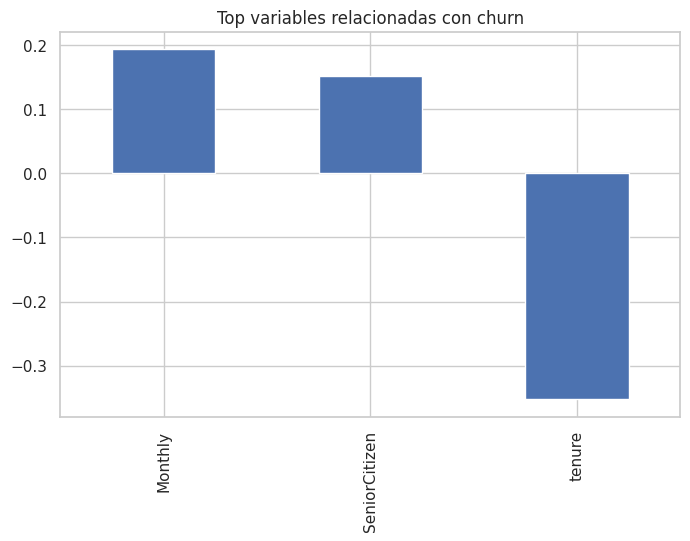

In [18]:
corr_matrix = df.select_dtypes(include="number").corr()

corr_churn = corr_matrix["Churn"].sort_values(ascending=False)

print("Variables mas correlacionadas con churn:")
print(corr_churn.head(10))

plt.figure(figsize=(8,5))
corr_churn.drop("Churn").head(10).plot(kind="bar")
plt.title("Top variables relacionadas con churn")
plt.show()

In [19]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4930, 6559)
Test: (2113, 6559)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


Modelo: Regresion Logistica
Accuracy: 0.77520113582584
Precision: 0.580168776371308
Recall: 0.49909255898366606
F1: 0.5365853658536586

Reporte:
              precision    recall  f1-score   support

         0.0       0.83      0.87      0.85      1562
         1.0       0.58      0.50      0.54       551

    accuracy                           0.78      2113
   macro avg       0.71      0.69      0.69      2113
weighted avg       0.77      0.78      0.77      2113



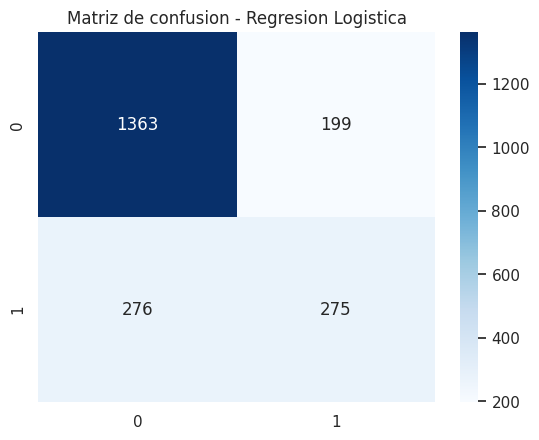


Modelo: Random Forest
Accuracy: 0.79649787032655
Precision: 0.6743515850144092
Recall: 0.4246823956442831
F1: 0.5211581291759465

Reporte:
              precision    recall  f1-score   support

         0.0       0.82      0.93      0.87      1562
         1.0       0.67      0.42      0.52       551

    accuracy                           0.80      2113
   macro avg       0.75      0.68      0.70      2113
weighted avg       0.78      0.80      0.78      2113



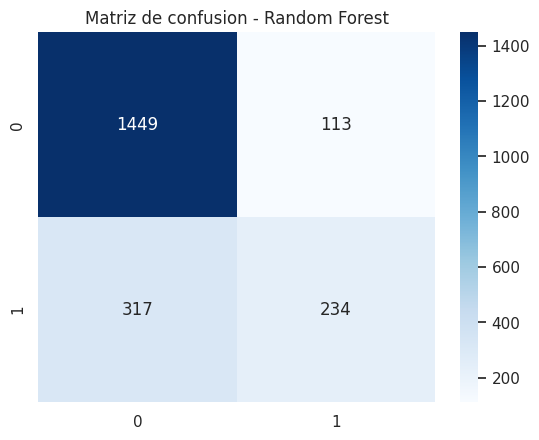

In [23]:
def evaluar(nombre, y_real, pred):

    print("\nModelo:", nombre)

    print("Accuracy:", accuracy_score(y_real, pred))
    print("Precision:", precision_score(y_real, pred))
    print("Recall:", recall_score(y_real, pred))
    print("F1:", f1_score(y_real, pred))

    print("\nReporte:")
    print(classification_report(y_real, pred))

    cm = confusion_matrix(y_real, pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Matriz de confusion - " + nombre)
    plt.show()


evaluar("Regresion Logistica", y_test, y_pred_log)
evaluar("Random Forest", y_test, y_pred_rf)

Variables mas importantes:
tenure                            0.120323
Monthly                           0.092745
Contract_Two year                 0.029777
PaymentMethod_Electronic check    0.028253
InternetService_Fiber optic       0.024777
TechSupport_Yes                   0.021030
Contract_One year                 0.020851
OnlineSecurity_Yes                0.019947
PaperlessBilling_Yes              0.019027
gender_Male                       0.018632
dtype: float64


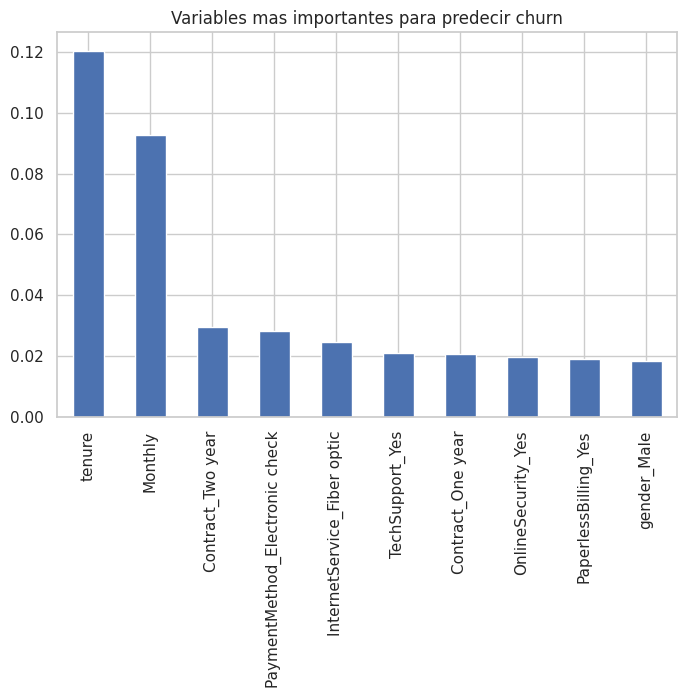

In [24]:
importancias = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Variables mas importantes:")
print(importancias.head(10))

plt.figure(figsize=(8,5))
importancias.head(10).plot(kind="bar")
plt.title("Variables mas importantes para predecir churn")
plt.show()

In [25]:
print("""
CONCLUSIONES

Los factores que mas influyen en la cancelacion de clientes son:

- tipo de contrato
- cargos mensuales
- tiempo de permanencia
- metodo de pago

El modelo Random Forest suele obtener mejor rendimiento
porque puede capturar relaciones mas complejas entre variables.

RECOMENDACIONES

1 Incentivar contratos de largo plazo
2 Detectar clientes con alto riesgo de cancelacion
3 Ofrecer promociones a clientes nuevos
4 Analizar planes con cargos mensuales altos
""")


CONCLUSIONES

Los factores que mas influyen en la cancelacion de clientes son:

- tipo de contrato
- cargos mensuales
- tiempo de permanencia
- metodo de pago

El modelo Random Forest suele obtener mejor rendimiento
porque puede capturar relaciones mas complejas entre variables.

RECOMENDACIONES

1 Incentivar contratos de largo plazo
2 Detectar clientes con alto riesgo de cancelacion
3 Ofrecer promociones a clientes nuevos
4 Analizar planes con cargos mensuales altos

